# Diabetes Prediction using Machine Learning

Diabetes, is a group of metabolic disorders in which there are high blood sugar levels over a prolonged period. Symptoms of high blood sugar include frequent urination, increased thirst, and increased hunger. If left untreated, diabetes can cause many complications. Acute complications can include diabetic ketoacidosis, hyperosmolar hyperglycemic state, or death. Serious long-term complications include cardiovascular disease, stroke, chronic kidney disease, foot ulcers, and damage to the eyes.

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Objective
We will try to build a machine learning model to accurately predict whether or not the patients in the dataset have diabetes or not?

## **Details about the dataset:**

The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

- **Pregnancies**: Number of times pregnant
- **Glucose**: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- **BloodPressure**: Diastolic blood pressure (mm Hg)
- **SkinThickness**: Triceps skin fold thickness (mm)
- **Insulin**: 2-Hour serum insulin (mu U/ml)
- **BMI**: Body mass index (weight in kg/(height in m)^2)
- **DiabetesPedigreeFunction**: Diabetes pedigree function
- **Age**: Age (years)
- **Outcome**: Class variable (0 or 1)

**Number of Observation Units: 768**

**Variable Number: 9**

**Result; The model created as a result of XGBoost hyperparameter optimization became the model with the lowest Cross Validation Score value. (0.90)**

# 1) Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import pandas as pd
from scipy.io import arff
from google.colab import drive
drive.mount('/content/drive')

# Import the os module
import os # Importing the os module

# Change directory to your Google Drive folder
os.chdir('/content/drive/My Drive/Colab Notebooks')  # Update path if necessary

data = arff.loadarff('diabet.arff')
train= pd.DataFrame(data[0])
train.head()

ValueError: mount failed

In [16]:
#Reading the dataset
import pandas as pd
from scipy.io import arff

# Load the ARFF file
data, meta = arff.loadarff('diabet.arff')

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Now you can work with the DataFrame 'df'
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'diabet.arff'

In [17]:
# The first 5 observation units of the data set were accessed.
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,b'tested_positive'
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,b'tested_negative'
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,b'tested_positive'
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,b'tested_negative'
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,b'tested_positive'


In [18]:
# The size of the data set was examined. It consists of 768 observation units and 9 variables.
df.shape

(768, 9)

In [19]:
#Feature information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    float64
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   insu    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    float64
 8   class   768 non-null    object 
dtypes: float64(8), object(1)
memory usage: 54.1+ KB


In [20]:
# Descriptive statistics of the data set accessed.
df.describe([0.10,0.25,0.50,0.75,0.90,0.95,0.99]).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
preg,768.0,3.845052,3.369578,0.000,0.000,1.00000,3.0000,6.00000,9.0000,10.00000,13.00000,17.00
plas,768.0,120.894531,31.972618,0.000,85.000,99.00000,117.0000,140.25000,167.0000,181.00000,196.00000,199.00
pres,768.0,69.105469,19.355807,0.000,54.000,62.00000,72.0000,80.00000,88.0000,90.00000,106.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.000,0.00000,23.0000,32.00000,40.0000,44.00000,51.33000,99.00
insu,768.0,79.799479,115.244002,0.000,0.000,0.00000,30.5000,127.25000,210.0000,293.00000,519.90000,846.00
mass,768.0,31.992578,7.884160,0.000,23.600,27.30000,32.0000,36.60000,41.5000,44.39500,50.75900,67.10
pedi,768.0,0.471876,0.331329,0.078,0.165,0.24375,0.3725,0.62625,0.8786,1.13285,1.69833,2.42
age,768.0,33.240885,11.760232,21.000,22.000,24.00000,29.0000,41.00000,51.0000,58.00000,67.00000,81.00


In [21]:
# The distribution of the Outcome variable was examined.
df["class"].value_counts()*100/len(df)

,count
class,
b'tested_negative',65.104167
b'tested_positive',34.895833


In [22]:
# The classes of the outcome variable were examined.
df['class'].value_counts()

,count
class,
b'tested_negative',500
b'tested_positive',268


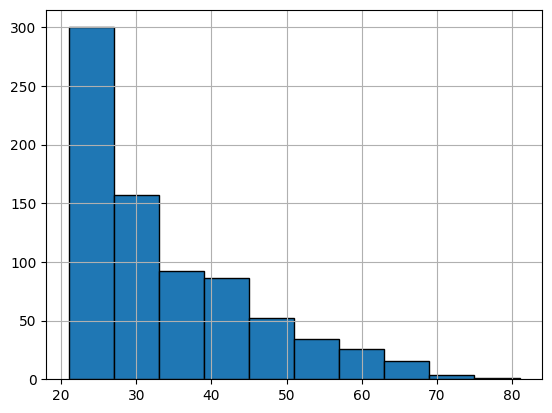

In [23]:
# The histagram of the Age variable was reached.
df["age"].hist(edgecolor = "black");

In [24]:
print("Max Age: " + str(df["age"].max()) + " Min Age: " + str(df["age"].min()))

Max Age: 81.0 Min Age: 21.0


<ipython-input-25-fbd577f09a54>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.age, bins = 20, ax=ax[0,0])
<ipython-input-25-fbd577f09a54>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.preg, bins = 20, ax=ax[0,1])
<ipython-input-25-fbd577f09a54>:5: UserWarning: 

`distplot` is a depre

<Axes: xlabel='mass', ylabel='Density'>

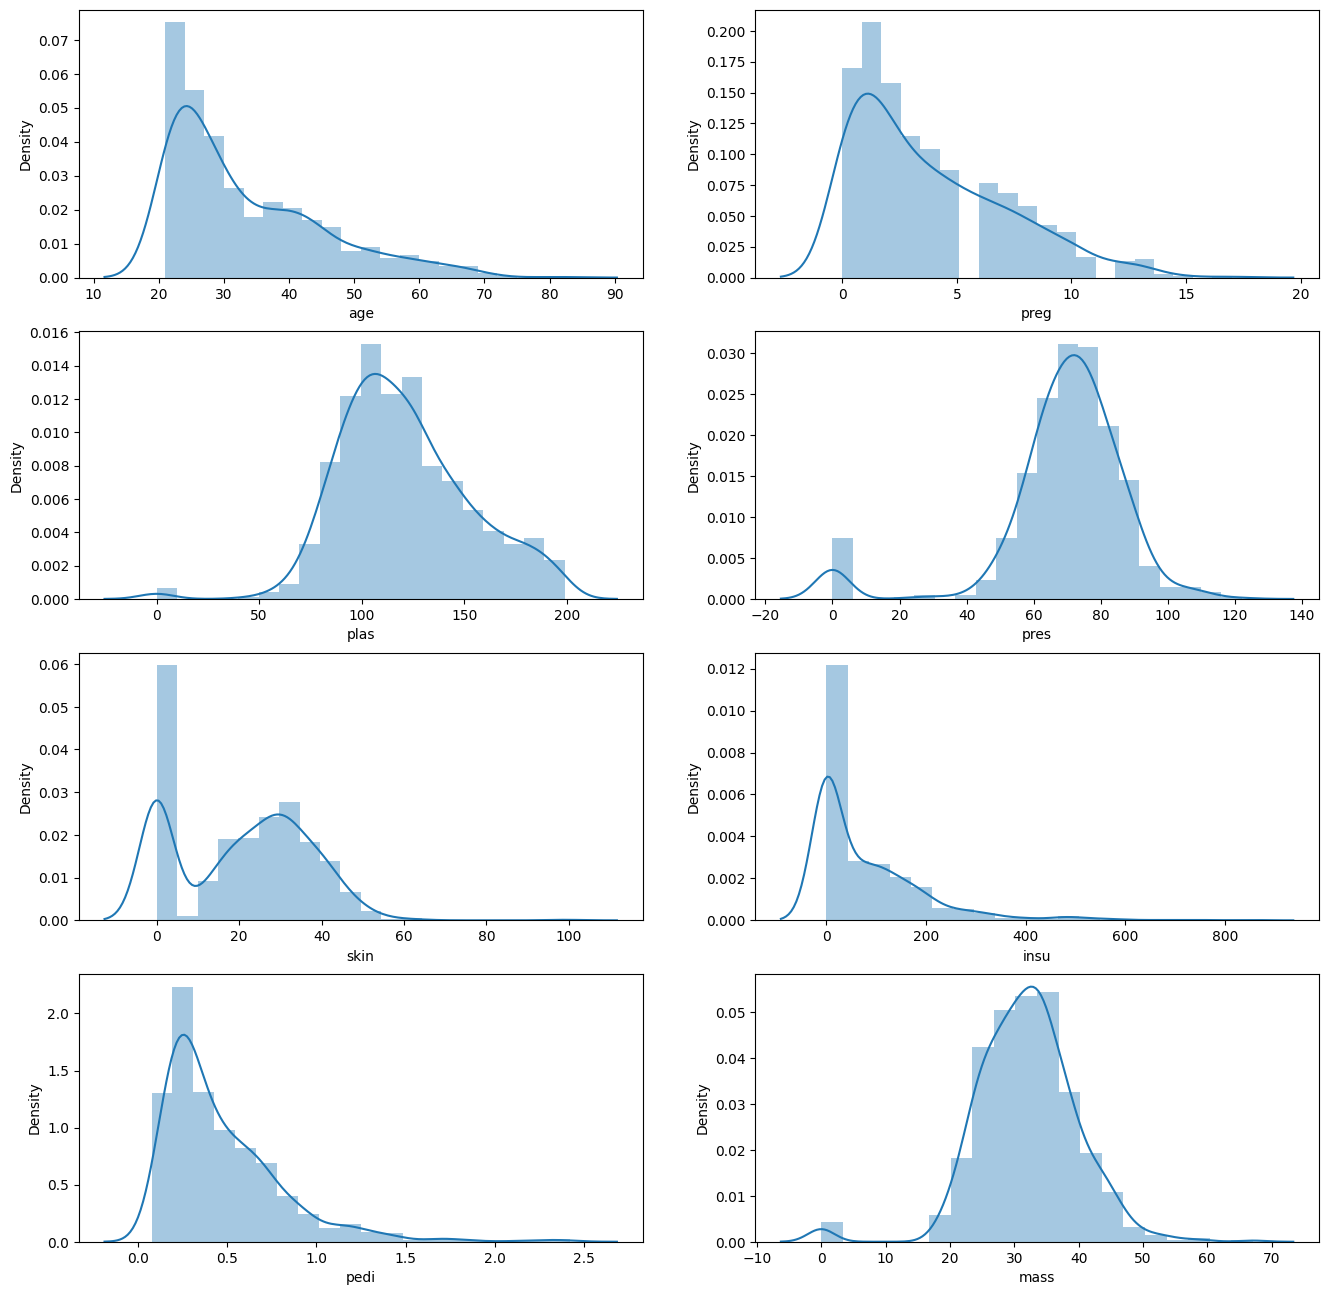

In [25]:
# Histogram and density graphs of all variables were accessed.
fig, ax = plt.subplots(4,2, figsize=(16,16))
sns.distplot(df.age, bins = 20, ax=ax[0,0])
sns.distplot(df.preg, bins = 20, ax=ax[0,1])
sns.distplot(df.plas, bins = 20, ax=ax[1,0])
sns.distplot(df.pres, bins = 20, ax=ax[1,1])
sns.distplot(df.skin, bins = 20, ax=ax[2,0])
sns.distplot(df.insu, bins = 20, ax=ax[2,1])
sns.distplot(df.pedi, bins = 20, ax=ax[3,0])
sns.distplot(df.mass, bins = 20, ax=ax[3,1])

In [26]:
df.groupby("class").agg({"preg":"mean"})

,preg
class,
b'tested_negative',3.298000
b'tested_positive',4.865672


In [27]:
df.groupby("class").agg({"age":"mean"})

,age
class,
b'tested_negative',31.190000
b'tested_positive',37.067164


In [28]:
df.groupby("class").agg({"age":"max"})

,age
class,
b'tested_negative',81.0
b'tested_positive',70.0


In [29]:
df.groupby("class").agg({"insu": "mean"})

,insu
class,
b'tested_negative',68.792000
b'tested_positive',100.335821


In [30]:
df.groupby("class").agg({"insu": "max"})

,insu
class,
b'tested_negative',744.0
b'tested_positive',846.0


In [31]:
df.groupby("class").agg({"plas": "mean"})

,plas
class,
b'tested_negative',109.980000
b'tested_positive',141.257463


In [32]:
df.groupby("class").agg({"plas": "max"})

,plas
class,
b'tested_negative',197.0
b'tested_positive',199.0


In [33]:
df.groupby("class").agg({"mass": "mean"})

,mass
class,
b'tested_negative',30.304200
b'tested_positive',35.142537


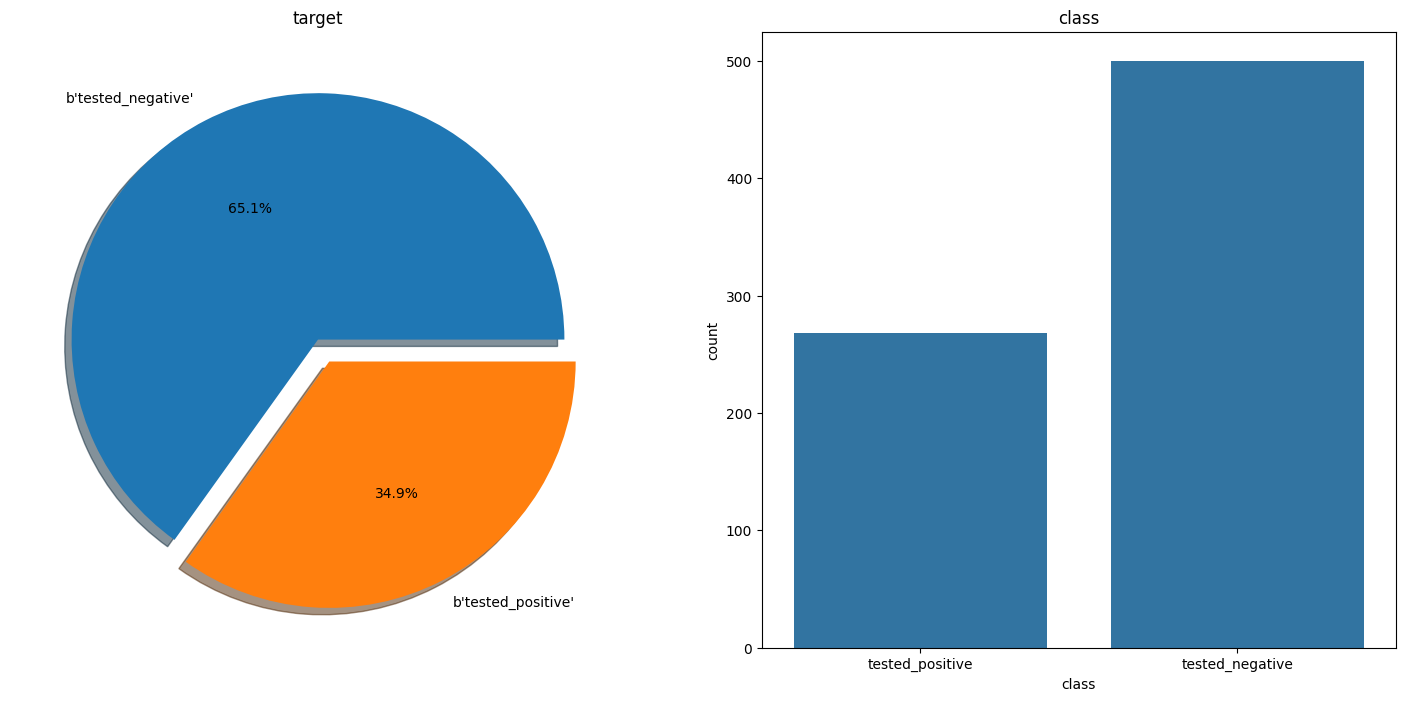

In [34]:
# The distribution of the outcome variable in the data was examined and visualized.
f,ax=plt.subplots(1,2,figsize=(18,8))
df['class'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('target')
ax[0].set_ylabel('')
# The issue was the 'data' argument was already implicitly specified due to a global variable named 'data'
# Changing the argument name to 'x' resolves the issue.
sns.countplot(x='class',data=df,ax=ax[1])
ax[1].set_title('class')
plt.show()

In [35]:
# Access to the correlation of the data set was provided. What kind of relationship is examined between the variables.
# If the correlation value is> 0, there is a positive correlation. While the value of one variable increases, the value of the other variable also increases.
# Correlation = 0 means no correlation.
# If the correlation is <0, there is a negative correlation. While one variable increases, the other variable decreases.
# When the correlations are examined, there are 2 variables that act as a positive correlation to the Salary dependent variable.
df['class'] = df['class'].map({b'tested_positive': 1, b'tested_negative': 0})

# Now calculate the correlation:
df.corr()

,preg,plas,pres,skin,insu,mass,pedi,age,class
preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plas,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pres,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insu,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
mass,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedi,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
class,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


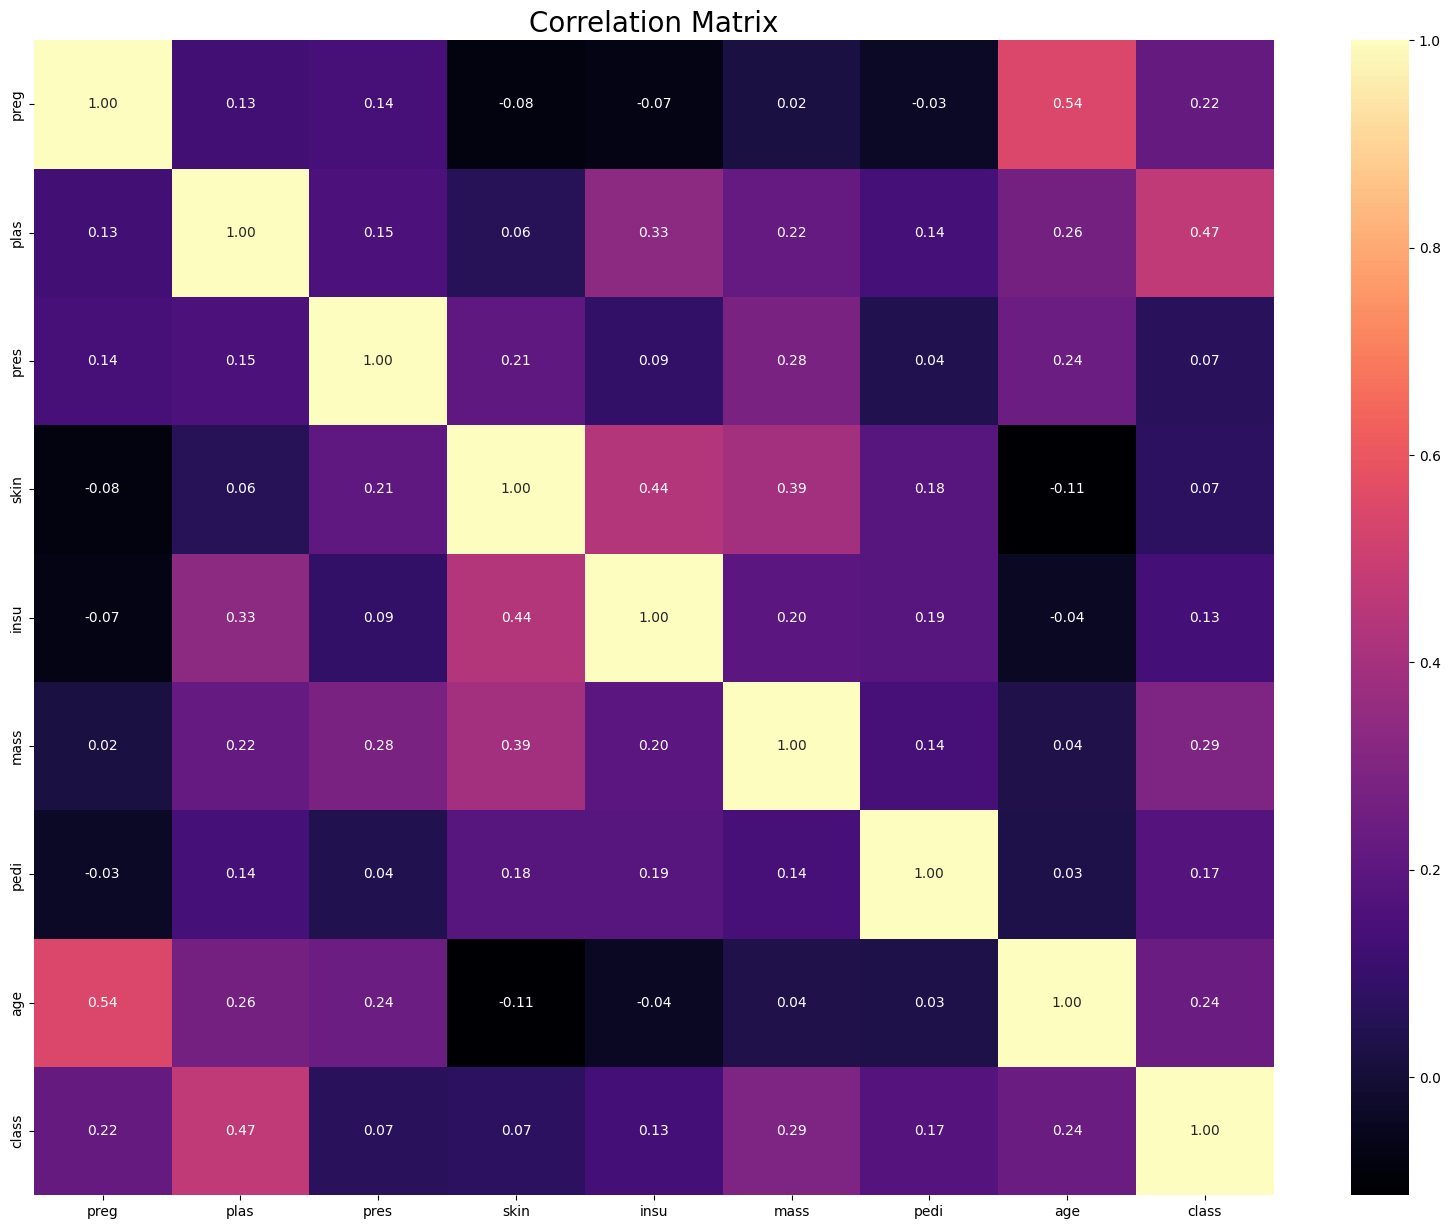

In [36]:
# Correlation matrix graph of the data set
f, ax = plt.subplots(figsize= [20,15])
sns.heatmap(df.corr(), annot=True, fmt=".2f", ax=ax, cmap = "magma" )
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

# 2) Data Preprocessing

## 2.1) Missing Observation Analysis

We saw on df.head() that some features contain 0, it doesn't make sense here and this indicates missing value Below we replace 0 value by NaN:

In [24]:
df[['plas','pres','skin','insu','mass']] = df[['plas','pres','skin','insu','mass']].replace(0,np.nan) # Changed np.NaN to np.nan

In [37]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


In [38]:
# Now, we can look at where are missing values
df.isnull().sum()

,0
preg,0
plas,0
pres,0
skin,0
insu,0
mass,0
pedi,0
age,0
class,0


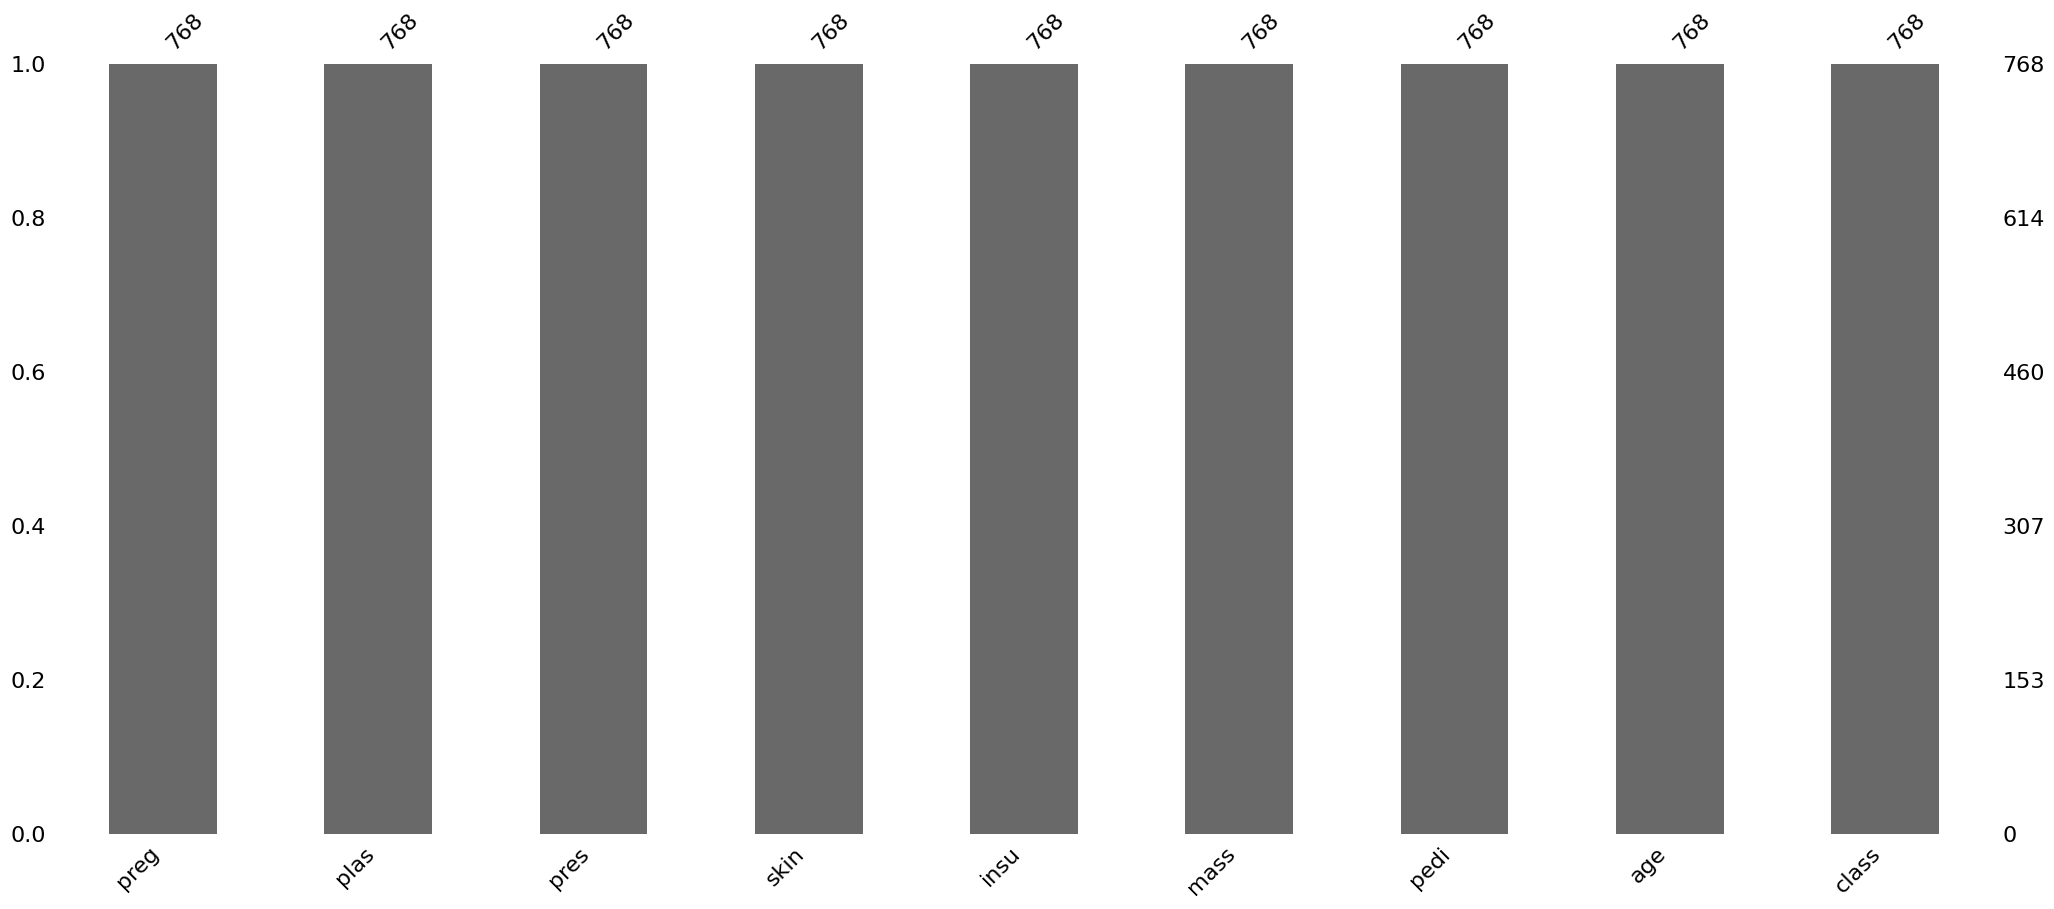

In [39]:
# Have been visualized using the missingno library for the visualization of missing observations.
# Plotting
import missingno as msno
msno.bar(df);

In [40]:
# The missing values ​​will be filled with the median values ​​of each variable.
def median_target(var):
    temp = df[df[var].notnull()]
    temp = temp[[var, 'class']].groupby(['class'])[[var]].median().reset_index()
    return temp

In [41]:
# The values to be given for incomplete observations are given the median value of people who are not sick and the median values of people who are sick.
columns = df.columns
columns = columns.drop("class")
for i in columns:
    median_target(i)
    df.loc[(df['class'] == 0 ) & (df[i].isnull()), i] = median_target(i)[i][0]
    df.loc[(df['class'] == 1 ) & (df[i].isnull()), i] = median_target(i)[i][1]

In [42]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


In [43]:
# Missing values were filled.
df.isnull().sum()

,0
preg,0
plas,0
pres,0
skin,0
insu,0
mass,0
pedi,0
age,0
class,0


## 2.2) Outlier Observation Analysis

In [44]:
# In the data set, there were asked whether there were any outlier observations compared to the 25% and 75% quarters.
# It was found to be an outlier observation.
for feature in df:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1- 1.5*IQR
    upper = Q3 + 1.5*IQR

    if df[(df[feature] > upper)].any(axis=None):
        print(feature,"yes")
    else:
        print(feature, "no")

preg yes
plas no
pres yes
skin yes
insu yes
mass yes
pedi yes
age yes
class no


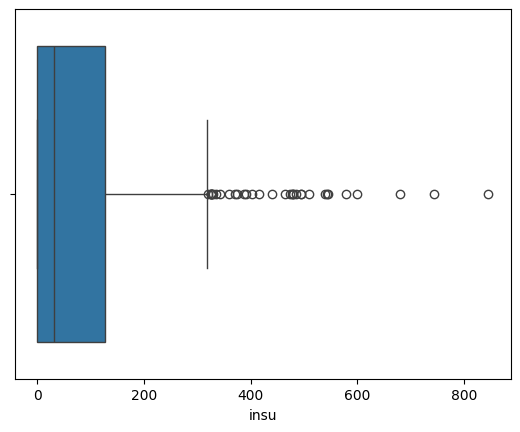

In [45]:
# The process of visualizing the Insulin variable with boxplot method was done. We find the outlier observations on the chart.
import seaborn as sns
sns.boxplot(x = df["insu"]);

In [46]:
#We conduct a stand alone observation review for the Insulin variable
#We suppress contradictory values
Q1 = df.insu.quantile(0.25)
Q3 = df.insu.quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df.loc[df["insu"] > upper,"insu"] = upper

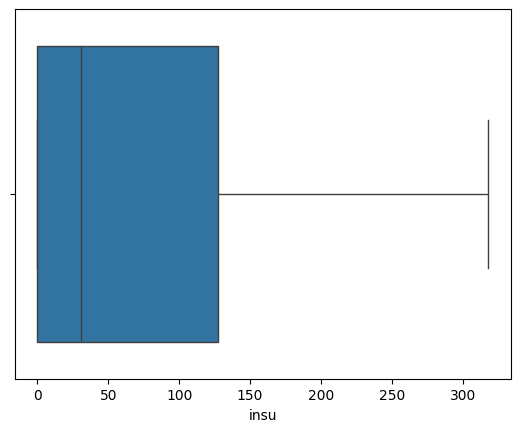

In [47]:
import seaborn as sns
sns.boxplot(x = df["insu"]);

## 2.3)  Local Outlier Factor (LOF)

In [48]:
# We determine outliers between all variables with the LOF method
from sklearn.neighbors import LocalOutlierFactor
lof =LocalOutlierFactor(n_neighbors= 10)
lof.fit_predict(df)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [49]:
df_scores = lof.negative_outlier_factor_
np.sort(df_scores)[0:30]

array([-2.28758733, -2.10500141, -2.05369597, -2.02885837, -2.00720763,
       -1.98655427, -1.95338702, -1.91601291, -1.88815728, -1.8134966 ,
       -1.80857804, -1.74187579, -1.73154315, -1.71639102, -1.71372358,
       -1.67587303, -1.64102097, -1.63498158, -1.62215678, -1.61146741,
       -1.59344933, -1.54582494, -1.54285259, -1.51413703, -1.50984155,
       -1.49974262, -1.48877158, -1.48495018, -1.47518401, -1.47089   ])

In [50]:
#We choose the threshold value according to lof scores
threshold = np.sort(df_scores)[7]
threshold

np.float64(-1.9160129109052675)

In [51]:
#We delete those that are higher than the threshold
outlier = df_scores > threshold
df = df[outlier]

In [52]:
# The size of the data set was examined.
df.shape

(760, 9)

# 3) Feature Engineering

Creating new variables is important for models. But you need to create a logical new variable. For this data set, some new variables were created according to BMI, Insulin and glucose variables.

In [53]:
# According to BMI, some ranges were determined and categorical variables were assigned.
NewBMI = pd.Series(["Underweight", "Normal", "Overweight", "Obesity 1", "Obesity 2", "Obesity 3"], dtype = "category")
df["NewBMI"] = NewBMI
df.loc[df["mass"] < 18.5, "NewBMI"] = NewBMI[0]
df.loc[(df["mass"] > 18.5) & (df["mass"] <= 24.9), "NewBMI"] = NewBMI[1]
df.loc[(df["mass"] > 24.9) & (df["mass"] <= 29.9), "NewBMI"] = NewBMI[2]
df.loc[(df["mass"] > 29.9) & (df["mass"] <= 34.9), "NewBMI"] = NewBMI[3]
df.loc[(df["mass"] > 34.9) & (df["mass"] <= 39.9), "NewBMI"] = NewBMI[4]
df.loc[df["mass"] > 39.9 ,"NewBMI"] = NewBMI[5]

In [54]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class,NewBMI
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1,Obesity 1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0,Overweight
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1,Normal
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Overweight
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,Obesity 3


In [55]:
# A categorical variable creation process is performed according to the insulin value.
def set_insulin(row):
    if row["insu"] >= 16 and row["insu"] <= 166:
        return "Normal"
    else:
        return "Abnormal"

In [56]:
# The operation performed was added to the dataframe.
df = df.assign(NewInsulinScore=df.apply(set_insulin, axis=1))

df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class,NewBMI,NewInsulinScore
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1,Obesity 1,Abnormal
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0,Overweight,Abnormal
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1,Normal,Abnormal
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Overweight,Normal
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,Obesity 3,Abnormal


In [57]:
# Some intervals were determined according to the glucose variable and these were assigned categorical variables.
NewGlucose = pd.Series(["Low", "Normal", "Overweight", "Secret", "High"], dtype = "category")
df["NewGlucose"] = NewGlucose
df.loc[df["plas"] <= 70, "NewGlucose"] = NewGlucose[0]
df.loc[(df["plas"] > 70) & (df["plas"] <= 99), "NewGlucose"] = NewGlucose[1]
df.loc[(df["plas"] > 99) & (df["plas"] <= 126), "NewGlucose"] = NewGlucose[2]
df.loc[df["plas"] > 126 ,"NewGlucose"] = NewGlucose[3]

In [58]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class,NewBMI,NewInsulinScore,NewGlucose
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1,Obesity 1,Abnormal,Secret
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0,Overweight,Abnormal,Normal
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1,Normal,Abnormal,Secret
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Overweight,Normal,Normal
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,Obesity 3,Abnormal,Secret


# 4) One Hot Encoding

Categorical variables in the data set should be converted into numerical values. For this reason, these transformation processes are performed with Label Encoding and One Hot Encoding method.

In [59]:
# Here, by making One Hot Encoding transformation, categorical variables were converted into numerical values. It is also protected from the Dummy variable trap.
df = pd.get_dummies(df, columns =["NewBMI","NewInsulinScore", "NewGlucose"], drop_first = True)

In [60]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1,True,False,False,False,False,False,False,False,False,True
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0,False,False,False,True,False,False,False,True,False,False
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1,False,False,False,False,False,False,False,False,False,True
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,False,False,False,True,False,True,False,True,False,False
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,False,False,True,False,False,False,False,False,False,True


In [61]:
# Here, by making One Hot Encoding transformation, categorical variables were converted into numerical values. It is also protected from the Dummy variable trap.
# Check if the columns exist before attempting to encode them
columns_to_encode = ["NewBMI", "NewInsulinScore", "NewGlucose"]
columns_to_encode = [col for col in columns_to_encode if col in df.columns]

if columns_to_encode:  # Only proceed if there are columns to encode
    df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
else:
    print("Columns to encode are not present in the DataFrame.")

Columns to encode are not present in the DataFrame.


In [62]:
# Here, by making One Hot Encoding transformation, categorical variables were converted into numerical values. It is also protected from the Dummy variable trap.
# Check if the columns exist before attempting to encode them
columns_to_encode = ["NewBMI", "NewInsulinScore", "NewGlucose"]
columns_to_encode = [col for col in columns_to_encode if col in df.columns]

if columns_to_encode:  # Only proceed if there are columns to encode
    df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
else:
    print("Columns to encode are not present in the DataFrame.")

# Immediately after creating the dummies (if any), extract the categorical columns into categorical_df:
categorical_cols = ['NewBMI_Obesity 1', 'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight', 'NewBMI_Underweight',
                   'NewInsulinScore_Normal', 'NewGlucose_Low', 'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret']
categorical_cols = [col for col in categorical_cols if col in df.columns]  # Filter existing columns

if categorical_cols:
    categorical_df = df[categorical_cols]
else:
    print("Categorical columns are not present in the DataFrame.")

df.head()  # This should now work as df is defined

Columns to encode are not present in the DataFrame.


,preg,plas,pres,skin,insu,mass,pedi,age,class,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1,True,False,False,False,False,False,False,False,False,True
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0,False,False,False,True,False,False,False,True,False,False
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1,False,False,False,False,False,False,False,False,False,True
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,False,False,False,True,False,True,False,True,False,False
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,False,False,True,False,False,False,False,False,False,True


In [63]:
y = df["class"]
X = df.drop(["class",'NewBMI_Obesity 1','NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight','NewBMI_Underweight',
                     'NewInsulinScore_Normal','NewGlucose_Low','NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret'], axis = 1)
cols = X.columns
index = X.index

In [64]:
X.head()

,preg,plas,pres,skin,insu,mass,pedi,age
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


In [65]:
# The variables in the data set are an effective factor in increasing the performance of the models by standardization.
# There are multiple standardization methods. These are methods such as" Normalize"," MinMax"," Robust" and "Scale".
from sklearn.preprocessing import RobustScaler
transformer = RobustScaler().fit(X)
X = transformer.transform(X)
X = pd.DataFrame(X, columns = cols, index = index)

In [66]:
X.head()

,preg,plas,pres,skin,insu,mass,pedi,age
0,0.6,0.738095,0.000000,0.37500,-0.282398,0.172043,0.663192,1.235294
1,-0.4,-0.761905,-0.333333,0.18750,-0.282398,-0.580645,-0.056026,0.117647
2,1.0,1.571429,-0.444444,-0.71875,-0.282398,-0.935484,0.780456,0.176471
3,-0.4,-0.666667,-0.333333,0.00000,0.444874,-0.419355,-0.535505,-0.470588
4,-0.6,0.476190,-1.777778,0.37500,1.017408,1.193548,4.991531,0.235294


In [67]:
categorical_df = df[['NewBMI_Obesity 1','NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight','NewBMI_Underweight',
                     'NewInsulinScore_Normal','NewGlucose_Low','NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret']]

# Now you can concatenate:
X = pd.concat([X,categorical_df], axis = 1)

In [68]:
X.head()

,preg,plas,pres,skin,insu,mass,pedi,age,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,0.6,0.738095,0.000000,0.37500,-0.282398,0.172043,0.663192,1.235294,True,False,False,False,False,False,False,False,False,True
1,-0.4,-0.761905,-0.333333,0.18750,-0.282398,-0.580645,-0.056026,0.117647,False,False,False,True,False,False,False,True,False,False
2,1.0,1.571429,-0.444444,-0.71875,-0.282398,-0.935484,0.780456,0.176471,False,False,False,False,False,False,False,False,False,True
3,-0.4,-0.666667,-0.333333,0.00000,0.444874,-0.419355,-0.535505,-0.470588,False,False,False,True,False,True,False,True,False,False
4,-0.6,0.476190,-1.777778,0.37500,1.017408,1.193548,4.991531,0.235294,False,False,True,False,False,False,False,False,False,True


In [69]:
y.head()

,class
0,1
1,0
2,1
3,0
4,1


# 5) Base Models

In [70]:
# Validation scores of all base models

models = []
models.append(('LR', LogisticRegression(random_state = 12345)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state = 12345)))
models.append(('RF', RandomForestClassifier(random_state = 12345)))
models.append(('SVM', SVC(gamma='auto', random_state = 12345)))
models.append(('XGB', GradientBoostingClassifier(random_state = 12345)))
models.append(("LightGBM", LGBMClassifier(random_state = 12345)))

# evaluate each model in turn
results = []
names = []

LR: 0.771053 (0.049653)
KNN: 0.761842 (0.039671)
CART: 0.702632 (0.064782)
RF: 0.756579 (0.048256)
SVM: 0.769737 (0.045675)
XGB: 0.752632 (0.055451)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 238, number of negative: 446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 715
[LightGBM] [Info] Number of data points in the train set: 684, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347953 -> initscore=-0.628048
[LightGBM] [Info] Start training from score -0.628048
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

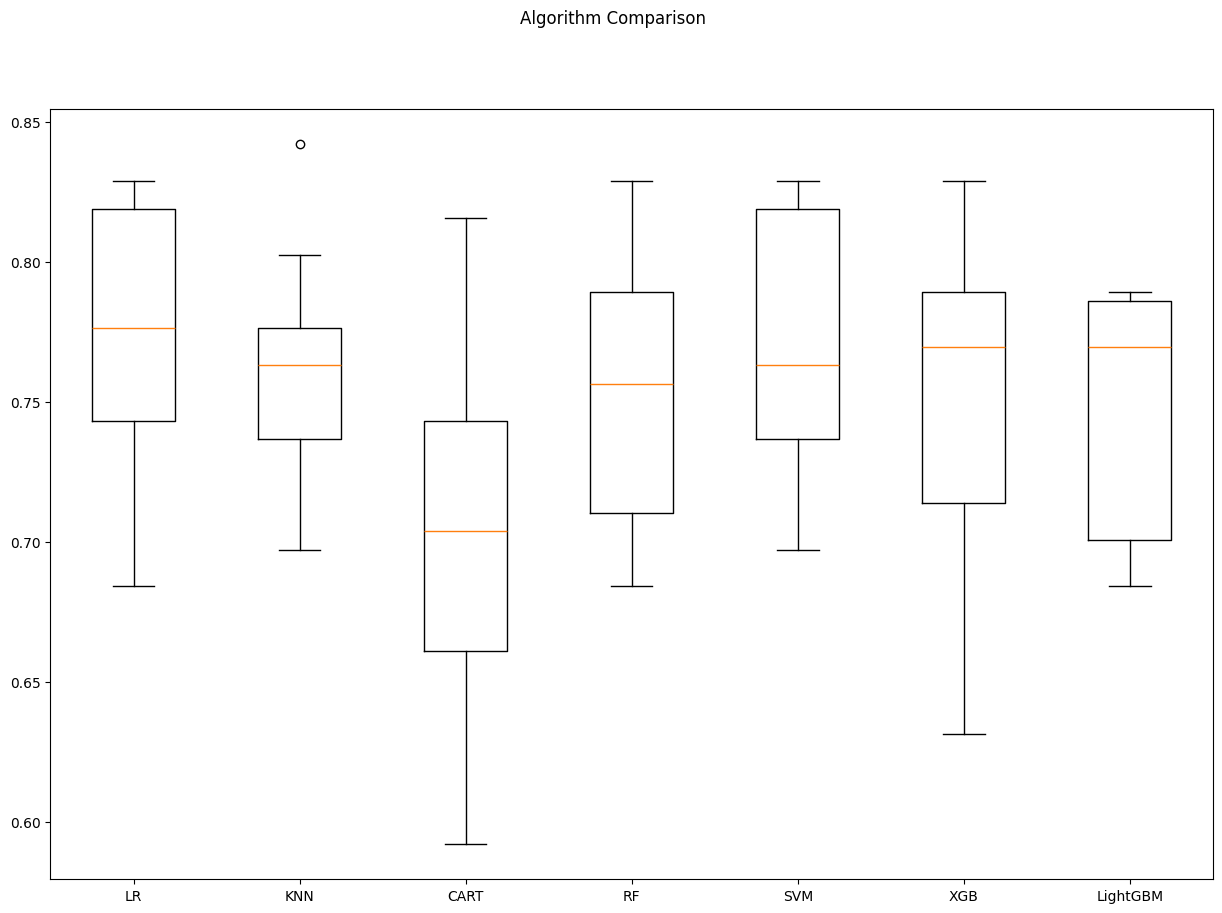

In [71]:
from IPython import get_ipython
from IPython.display import display
from sklearn.model_selection import KFold # Importing KFold
for name, model in models:

        # Setting shuffle=True to allow random_state to have an effect
        kfold = KFold(n_splits = 10, shuffle=True, random_state = 12345)
        cv_results = cross_val_score(model, X, y, cv = 10, scoring= "accuracy")
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)

# boxplot algorithm comparison
fig = plt.figure(figsize=(15,10))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# 6) Model Tuning

### 1) Random Forests Tuning

In [72]:
rf_params = {"n_estimators" :[100,200,500,1000],
             "max_features": [3,5,7],
             "min_samples_split": [2,5,10,30],
            "max_depth": [3,5,8,None]}

In [73]:
rf_model = RandomForestClassifier(random_state = 12345)

In [74]:
gs_cv = GridSearchCV(rf_model,
                    rf_params,
                    cv = 10,
                    n_jobs = -1,
                    verbose = 2).fit(X, y)

Fitting 10 folds for each of 192 candidates, totalling 1920 fits


In [65]:
gs_cv.best_params_

{'max_depth': 8,
 'max_features': 7,
 'min_samples_split': 2,
 'n_estimators': 500}

### 1.1) Final Model Installation

In [12]:
rf_tuned = RandomForestClassifier(**gs_cv.best_params_)

NameError: name 'gs_cv' is not defined

In [67]:
rf_tuned = rf_tuned.fit(X,y)

In [68]:
cross_val_score(rf_tuned, X, y, cv = 10).mean()

np.float64(0.8921052631578948)

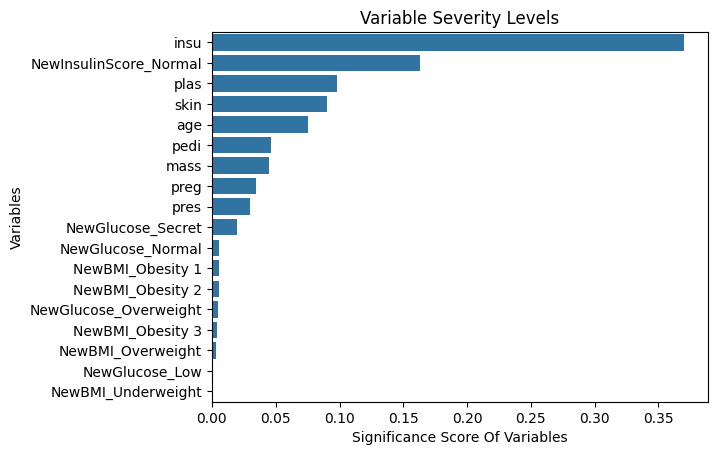

In [69]:
feature_imp = pd.Series(rf_tuned.feature_importances_,
                        index=X.columns).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Significance Score Of Variables')
plt.ylabel('Variables')
plt.title("Variable Severity Levels")
plt.show()

### 2) LightGBM Tuning

In [10]:
lgbm = LGBMClassifier(random_state = 12345)

In [71]:
lgbm_params = {"learning_rate": [0.01, 0.03, 0.05, 0.1, 0.5],
              "n_estimators": [500, 1000, 1500],
              "max_depth":[3,5,8]}


In [11]:
gs_cv = GridSearchCV(lgbm,
                     lgbm_params,
                     cv = 10,
                     n_jobs = -1,
                     verbose = 2).fit(X, y)

NameError: name 'lgbm_params' is not defined

In [73]:
gs_cv.best_params_

{'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 500}

### 2.1) Final Model Installation

In [8]:
lgbm_tuned = LGBMClassifier(**gs_cv.best_params_).fit(X,y)

NameError: name 'gs_cv' is not defined

In [7]:
cross_val_score(lgbm_tuned, X, y, cv = 10).mean()

NameError: name 'lgbm_tuned' is not defined

In [6]:
feature_imp = pd.Series(lgbm_tuned.feature_importances_,
                        index=X.columns).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Significance Score Of Variables')
plt.ylabel('Variables')
plt.title("Variable Severity Levels")
plt.show()

NameError: name 'lgbm_tuned' is not defined

### 3) XGBoost Tuning

In [4]:
xgb = GradientBoostingClassifier(random_state = 12345)

In [78]:
xgb_params = {
    "learning_rate": [0.01, 0.1, 0.2, 1],
    "min_samples_split": np.linspace(0.1, 0.5, 10),
    "max_depth":[3,5,8],
    "subsample":[0.5, 0.9, 1.0],
    "n_estimators": [100,1000]}

In [5]:
xgb_cv_model  = GridSearchCV(xgb,xgb_params, cv = 10, n_jobs = -1, verbose = 2).fit(X, y)

NameError: name 'xgb_params' is not defined

In [1]:
xgb_cv_model.best_params_

NameError: name 'xgb_cv_model' is not defined

### 3.1) Final Model Installation

In [ ]:
xgb_tuned = GradientBoostingClassifier(**xgb_cv_model.best_params_).fit(X,y)

In [ ]:
cross_val_score(xgb_tuned, X, y, cv = 10).mean()

In [ ]:
feature_imp = pd.Series(xgb_tuned.feature_importances_,
                        index=X.columns).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Significance Score Of Variables')
plt.ylabel('Variables')
plt.title("Variable Severity Levels")
plt.show()

# 7) Comparison of Final Models

In [ ]:
models = []

models.append(('RF', RandomForestClassifier(random_state = 12345, max_depth = 8, max_features = 7, min_samples_split = 2, n_estimators = 500)))
models.append(('XGB', GradientBoostingClassifier(random_state = 12345, learning_rate = 0.1, max_depth = 5, min_samples_split = 0.1, n_estimators = 100, subsample = 1.0)))
models.append(("LightGBM", LGBMClassifier(random_state = 12345, learning_rate = 0.01,  max_depth = 3, n_estimators = 1000)))

# evaluate each model in turn
results = []
names = []

In [ ]:
for name, model in models:

        kfold = KFold(n_splits = 10, random_state = 12345)
        cv_results = cross_val_score(model, X, y, cv = 10, scoring= "accuracy")
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)

# boxplot algorithm comparison
fig = plt.figure(figsize=(15,10))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# 8) Reporting

The aim of this study was to create classification models for the diabetes data set and to predict whether a person is sick by establishing models and to obtain maximum validation scores in the established models. The work done is as follows:

1) Diabetes Data Set read.

2) With Exploratory Data Analysis; The data set's structural data were checked.
The types of variables in the dataset were examined. Size information of the dataset was accessed. The 0 values in the data set are missing values. Primarily these 0 values were replaced with NaN values. Descriptive statistics of the data set were examined.

3) Data Preprocessing section;
df for: The NaN values missing observations were filled with the median values of whether each variable was sick or not. The outliers were determined by LOF and dropped. The X variables were standardized with the rubost method..

4) During Model Building;
Logistic Regression, KNN, SVM, CART, Random Forests, XGBoost, LightGBM like using machine learning models Cross Validation Score were calculated. Later Random Forests, XGBoost, LightGBM hyperparameter optimizations optimized to increase Cross Validation value.

5) Result;
The model created as a result of XGBoost hyperparameter optimization became the model with the lowest Cross Validation Score value. (0.90)